<h1 style="text-align:center;">AF3 Motif Builder</h1>

In [3]:
import glob
import os
import shutil
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product

from Bio.PDB import MMCIFParser
from Bio.SeqUtils import seq1
from scipy.stats import spearmanr

# Build motif

/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_95793/4013882279.py:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(f'{step}_{peptide}/chainA_B_random_pair_{peptide}_output.txt', delim_whitespace=True)[['id', 'AF3_iptm_pair_mean']]
/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_95793/4013882279.py:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(f'{step}_{peptide}/chainA_B_random_pair_{peptide}_output.txt', delim_whitespace=True)[['id', 'AF3_iptm_pair_mean']]
/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_95793/4013882279.py:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(f'{step}_{peptide}/chainA_B_random_pair

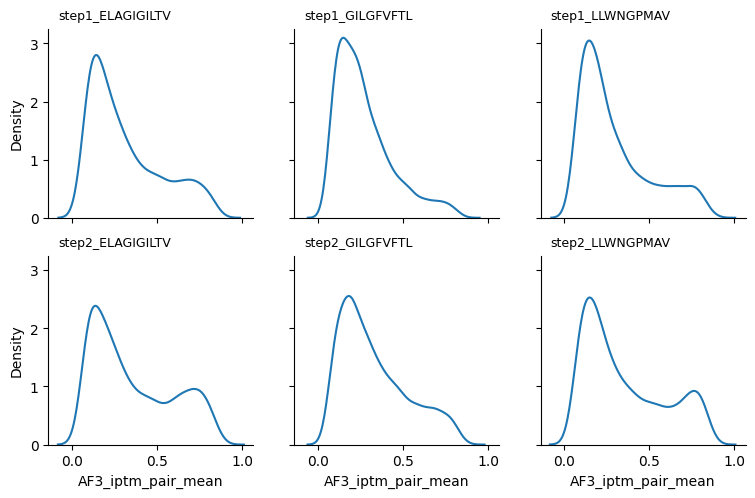

In [2]:
fig, axes = plt.subplots(2,3, figsize=(3*3,2.7*2), sharex=True, sharey=True)

steps = ['step1', 'step2']
peptides = ['ELAGIGILTV', 'GILGFVFTL', 'LLWNGPMAV']

for cnt1, step in enumerate(steps):
    for cnt2, peptide in enumerate(peptides):
        ax = axes[cnt1][cnt2]
        df = pd.read_csv(f'{step}_{peptide}/chainA_B_random_pair_{peptide}_output.txt', delim_whitespace=True)[['id', 'AF3_iptm_pair_mean']]

        sns.kdeplot(df, x='AF3_iptm_pair_mean', ax=ax)
        sns.despine()
        ax.text(0.05, 1.05, f'{step}_{peptide}', transform=ax.transAxes, fontsize=9)

/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_26218/256118517.py:12: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df1 = pd.read_csv(f'dummy_chains/{step}_dummy_{peptide}/chainA_dummyB/chainA_dummyB_pair_{peptide}_output.txt', delim_whitespace=True)[['id', 'AF3_iptm_pair_mean']]
/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_26218/256118517.py:13: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df2 = pd.read_csv(f'dummy_chains/{step}_dummy_{peptide}/dummyA_chainB/dummyA_chainB_pair_{peptide}_output.txt', delim_whitespace=True)[['id', 'AF3_iptm_pair_mean']]


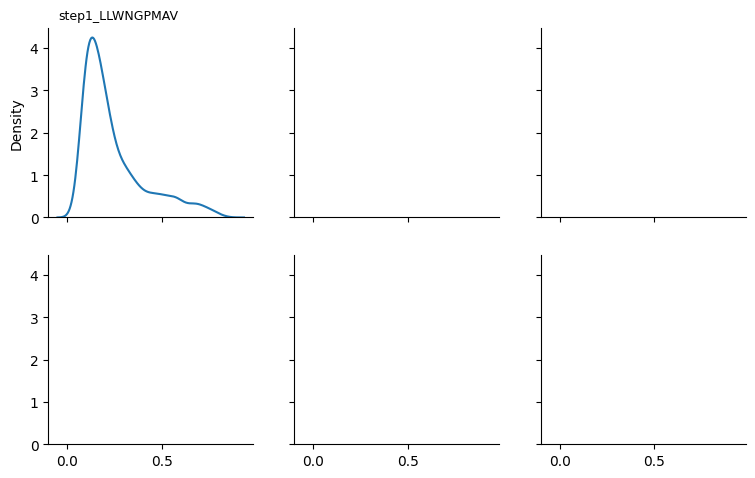

In [4]:
fig, axes = plt.subplots(2,3, figsize=(3*3,2.7*2), sharex=True, sharey=True)

steps = ['step1', 'step2']
peptides = ['ELAGIGILTV', 'GILGFVFTL', 'LLWNGPMAV']

steps = ['step1']
peptides = ['LLWNGPMAV']

for cnt1, step in enumerate(steps):
    for cnt2, peptide in enumerate(peptides):
        ax = axes[cnt1][cnt2]
        df1 = pd.read_csv(f'dummy_chains/{step}_dummy_{peptide}/chainA_dummyB/chainA_dummyB_pair_{peptide}_output.txt', delim_whitespace=True)[['id', 'AF3_iptm_pair_mean']]
        df2 = pd.read_csv(f'dummy_chains/{step}_dummy_{peptide}/dummyA_chainB/dummyA_chainB_pair_{peptide}_output.txt', delim_whitespace=True)[['id', 'AF3_iptm_pair_mean']]

        df = pd.concat([df1, df2])
        sns.kdeplot(df, x='AF3_iptm_pair_mean', ax=ax)
        sns.despine()
        ax.text(0.05, 1.05, f'{step}_{peptide}', transform=ax.transAxes, fontsize=9)

In [ ]:
# prepaire csv for motif building
steps = {'step1':0.5,
        'step2':0.8}

peptides = ['ELAGIGILTV', 'GILGFVFTL', 'LLWNGPMAV']

for step, threshold in steps.items():
    for peptide in peptides:
        df = pd.read_csv(f'{step}_{peptide}/chainA_B_random_pair_{peptide}_output.txt', delim_whitespace=True)[['id', 'AF3_iptm_pair_mean']]
        anno = pd.read_csv(f'{step}_{peptide}/chainA_B_random_pair_{peptide}_input.txt', delim_whitespace=True)

        df = pd.merge(df, anno, on='id')
        df.to_csv(f'{step}_{peptide}/baseline.txt', sep="\t", index=False)
            
        df = df[df['AF3_iptm_pair_mean'] > threshold]
        df['model'] = peptide
        df.to_csv(f'{step}_{peptide}/model.txt', sep="\t", index=False) 

/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_26218/496640326.py:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(f'{step}_{peptide}/chainA_B_random_pair_{peptide}_output.txt', delim_whitespace=True)[['id', 'AF3_iptm_pair_mean']]
/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_26218/496640326.py:10: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  anno = pd.read_csv(f'{step}_{peptide}/chainA_B_random_pair_{peptide}_input.txt', delim_whitespace=True)
/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_26218/496640326.py:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(f'{step}_{peptide}/chainA_B_random_pair_{peptide}_output.txt', delim_w

In [10]:
# prepaire csv for motif building
steps = {'step1':0.5,
        'step2':0.8}

peptides = ['ELAGIGILTV', 'GILGFVFTL', 'LLWNGPMAV']

steps = {'step1':0.5}
peptides = ['LLWNGPMAV']
chains = ['chainA_dummyB', 'dummyA_chainB']

for step, threshold in steps.items():
    for peptide in peptides:
        for chain in chains:
            df = pd.read_csv(f'dummy_chains/{step}_dummy_{peptide}/{chain}/{chain}_pair_{peptide}_output.txt', delim_whitespace=True)[['id', 'AF3_iptm_pair_mean']]
            anno = pd.read_csv(f'dummy_chains/{step}_dummy_{peptide}/{chain}/{chain}_pair_{peptide}_input.txt', delim_whitespace=True)
            df = pd.merge(df, anno, on='id')

            df.to_csv(f'dummy_chains/{step}_dummy_{peptide}/{chain}/baseline.txt', sep="\t", index=False)
                
            df = df[df['AF3_iptm_pair_mean'] > threshold]
            df['model'] = peptide
            df.to_csv(f'dummy_chains/{step}_dummy_{peptide}/{chain}/model.txt', sep="\t", index=False) 

/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_26218/2037594317.py:14: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(f'dummy_chains/{step}_dummy_{peptide}/{chain}/{chain}_pair_{peptide}_output.txt', delim_whitespace=True)[['id', 'AF3_iptm_pair_mean']]
/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_26218/2037594317.py:15: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  anno = pd.read_csv(f'dummy_chains/{step}_dummy_{peptide}/{chain}/{chain}_pair_{peptide}_input.txt', delim_whitespace=True)
/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_26218/2037594317.py:14: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(f'dummy_chains/{step}_dummy

# Motif accuracy

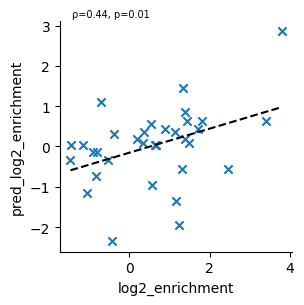

In [35]:
step = 'step1'
peptide = 'LLWNGPMAV'
chains = ['chainA_dummyB', 'dummyA_chainB']

ground_truth = pd.read_csv(f'{peptide}/enrichment.csv')[['segment', 'gene', 'log2_enrichment', 'rank']]

lst = []
for name, group in ground_truth.groupby('segment'):
    group = group.sort_values(by='log2_enrichment', ascending=False)
    group = group.iloc[:10]
    lst.append(group)
    
ground_truth = pd.concat(lst)

lst = []
for chain in chains:    
    df = pd.read_csv(f'dummy_chains/{step}_dummy_{peptide}/{chain}/enrichment.csv')
    lst.append(df)

df = pd.concat(lst)

df = df[['segment', 'gene', 'log2_enrichment', 'rank']]
df = df.rename(columns={'log2_enrichment':'pred_log2_enrichment', 'rank':'pred_rank'})

df = pd.merge(ground_truth, df, on='gene')

# correlation enrichment 
fig, ax = plt.subplots(1, 1, figsize=(3,3))

sns.scatterplot(df, x='log2_enrichment', y='pred_log2_enrichment', marker='x', linewidth=1.5, ax=ax)

# Compute Spearman correlation
rho, pval = spearmanr(df['log2_enrichment'], df['pred_log2_enrichment'])

# Draw a smooth line showing monotonic trend
sns.regplot(x=df['log2_enrichment'], y=df['pred_log2_enrichment'], ax=ax, scatter=False, color='black', line_kws={'lw':1.5, 'ls':'--'}, ci=False)

# Add rho to the plot
# Format string
if pval < 0.01:
    p_str = f"{pval:.1e}"   # scientific notation
else:
    p_str = f"{pval:.2f}"   # fixed-point

ax.text(
0.05, 1.05, f"ρ={rho:.2f}, p={p_str}", 
transform=ax.transAxes, fontsize=7, verticalalignment='top'
)
sns.despine()


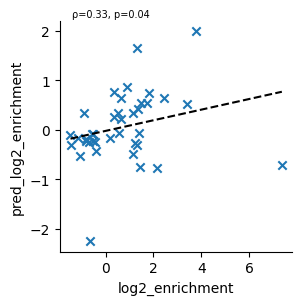

In [36]:
step = 'step1'
peptide = 'LLWNGPMAV'

ground_truth = pd.read_csv(f'{peptide}/enrichment.csv')[['segment', 'gene', 'log2_enrichment', 'rank']]

lst = []
for name, group in ground_truth.groupby('segment'):
    group = group.sort_values(by='log2_enrichment', ascending=False)
    group = group.iloc[:10]
    lst.append(group)
    
ground_truth = pd.concat(lst)

df = pd.read_csv(f'{step}_{peptide}/enrichment.csv')

df = df[['gene', 'log2_enrichment', 'rank']]
df = df.rename(columns={'log2_enrichment':'pred_log2_enrichment', 'rank':'pred_rank'})

df = pd.merge(ground_truth, df, on='gene')
df['segment'] = df['gene'].str[:4]

# correlation enrichment 
fig, ax = plt.subplots(1, 1, figsize=(3,3))

sns.scatterplot(df, x='log2_enrichment', y='pred_log2_enrichment', marker='x', linewidth=1.5, ax=ax)

# Compute Spearman correlation
rho, pval = spearmanr(df['log2_enrichment'], df['pred_log2_enrichment'])

# Draw a smooth line showing monotonic trend
sns.regplot(x=df['log2_enrichment'], y=df['pred_log2_enrichment'], ax=ax, scatter=False, color='black', line_kws={'lw':1.5, 'ls':'--'}, ci=False)

# Add rho to the plot
# Format string
if pval < 0.01:
    p_str = f"{pval:.1e}"   # scientific notation
else:
    p_str = f"{pval:.2f}"   # fixed-point

ax.text(
0.05, 1.05, f"ρ={rho:.2f}, p={p_str}", 
transform=ax.transAxes, fontsize=7, verticalalignment='top'
)
sns.despine()


# PCA of CDR loops

In [ ]:
def extract_cdr_coords(pdb_path, cdr_dict, chain_map={"TRA":"A","TRB":"B"}):
    """
    Extract coordinates of CDRs based on the respective sequences.
    """
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure("pdb", pdb_path)
    
    cdr_coords = {}
    
    for chain_label, chain_id in chain_map.items():
        chain_obj = structure[0][chain_id]
        
        # Get all residues with C-alpha
        residues = [res for res in chain_obj if res.id[0] == " " and "CA" in res]
        
        # Convert 3-letter PDB codes to 1-letter
        seq = "".join([seq1(res.get_resname()) for res in residues])
        
        cdr_coords[chain_label] = {}
        
        # loop over CDR1/2/3
        for i, cdr_key in enumerate([f"CDR1{chain_label[-1]}", f"CDR2{chain_label[-1]}", f"CDR3{chain_label[-1]}"], 1):
            cdr_seq = cdr_dict[cdr_key].upper()
            L = len(cdr_seq)
            
            # find CDR sequence in the chain sequence
            start_idx = seq.find(cdr_seq)
            if start_idx == -1:
                print(f"Warning: CDR {cdr_key} sequence not found in chain {chain_id} of {pdb_path}")
                return None
            
            end_idx = start_idx + L
            
            # extract C-alpha coordinates
            coords = np.array([res["CA"].get_coord() for res in residues[start_idx:end_idx]])
            cdr_coords[chain_label][f"cdr{i}"] = coords
            
    return cdr_coords

def build_coord_matrix(cdr_coord_dict, min_cdr_lengths):
    """
    Build coordinate matrix with fixed-length CDRs.
    """
    coord_matrix = []
    for tcr, chains in cdr_coord_dict.items():
        vec = []
        for chain, cdrs in chains.items():
            for cdr_name in ["cdr1","cdr2"]:
                coords = cdrs[cdr_name]
                L = min_cdr_lengths[chain][cdr_name]
                # first 2 + last L-2
                selected = np.vstack([coords[:2], coords[-(L-2):]])
                vec.extend(selected.flatten())
            # CDR3: first 5 + last L-5
            coords = cdrs["cdr3"]
            L = min_cdr_lengths[chain]["cdr3"]
            selected = np.vstack([coords[:5], coords[-(L-5):]])
            vec.extend(selected.flatten())
        coord_matrix.append(vec)
    
    return np.array(coord_matrix)

In [ ]:
# align models to experimental stuctures with lowest pdb id. 
tmp = glob.glob(f'../260202_YF-modes/pdbs_clean/*.pdb')
tmp.sort()
ref_file = tmp[0]

batches = ['LAU5013_AF3_chainA', 'LAU5013_AF3_chainA_randomB']
      
for batch in batches:
    batch_short = batch.split('_')[2:]
    batch_short = '_'.join(batch_short)

    indir = f'{batch}/AF3_outputs/model_pdb'
    outdir = f'{batch}/AF3_outputs/model_pdb_trunc'
    os.makedirs(outdir, exist_ok=True)

    pdbs = glob.glob(f'{indir}/*.pdb')
    parser = PDBParser(QUIET=True)
    io = PDBIO()

    for pdb in pdbs:
        structure = parser.get_structure(os.path.basename(pdb), pdb)
        chain_a = structure[0]['A']

        residues_to_delete = [res for res in chain_a if 1 <= res.id[1] <= 24]
        for res in residues_to_delete:
            chain_a.detach_child(res.id)

        out_path = os.path.join(outdir, os.path.basename(pdb))
        io.set_structure(structure)
        io.save(out_path)

    # perfom alignment
    indir = f'{batch}/AF3_outputs/model_pdb_trunc'
    outdir = f'{batch}/AF3_outputs/model_pdb_align_exp'
    os.makedirs(outdir, exist_ok=True)
    mobile_files = glob.glob(f'{indir}/*.pdb')
    mobile_files.sort()
    
    align_pdbs(ref_file, mobile_files, outdir)


# Curate file with CDR plddts for motif annotation

In [12]:
def extract_cdr_plddt(cif_path, cdr_dict, chain_map={"TRA":"TCRA","TRB":"TCRB"}, epitope_chains=["MHC","PEPTIDE"], threshold=10):
    """
    Extract plddt of CDRs based on the respective sequences.
    """

    parser = MMCIFParser(QUIET=True)
    structure = parser.get_structure("cif", cif_path)
    model = structure[0]

    cdr_plddt = {}

    for chain_label, chain_id in chain_map.items():
        chain_obj = model[chain_id]

        residues = [res for res in chain_obj if res.id[0] == " " and "CA" in res]
        seq = "".join(seq1(res.get_resname()) for res in residues)

        cdr_dict_chain = {}
        for key, value in cdr_dict.items():
            if key.endswith(chain_id[-1]):
                cdr_dict_chain[key] = value

        for cdr, cdr_seq in cdr_dict_chain.items():
            L = len(cdr_seq)

            start_idx = seq.find(cdr_seq)
            if start_idx == -1:
                print(f"Warning: {cdr} not found in {chain_id} of {cif_path}")
                continue

            end_idx = start_idx + L

            plddts = []
            for res in residues[start_idx:end_idx]:
                res_plddts = []
                for atom in res.get_atoms():
                    res_plddts.append(atom.get_bfactor())

                mean_res_plddts = np.mean(res_plddts) / 100
                plddts.append(np.round(mean_res_plddts, 2))

            cdr_plddt[cdr] = np.array(plddts) 

    return cdr_plddt

def split_cdr3(cdr3, v_gene, j_gene, v_ref, j_ref):
    """
    Split CDR3 into V, insertion, and J sequences.
    Returns: v_seq_str, insertion_seq_str, j_seq_str
    """
    # Get reference sequences
    v_seq = v_ref.loc[v_ref['Gene']==v_gene, 'CDR3'].values
    j_seq = j_ref.loc[j_ref['Gene']==j_gene, 'CDR3'].values
    
    if len(v_seq)==0 or len(j_seq)==0:
        # If reference is missing, put everything as 'Unknown'
        return None, None
    
    v_seq = v_seq[0]
    j_seq = j_seq[0]
    
    # Match V at the start
    v_len = 0
    for i in range(min(len(v_seq), len(cdr3))):
        if cdr3[i] == v_seq[i]:
            v_len += 1
        else:
            break
    
    # Match J at the end
    j_len = 0
    for i in range(1, min(len(j_seq), len(cdr3))+1):
        if cdr3[-i] == j_seq[-i]:
            j_len += 1
        else:
            break
    
    v_part = cdr3[:v_len]
    j_part = cdr3[len(cdr3)-j_len:] if j_len > 0 else ''
    insertion_part = cdr3[v_len:len(cdr3)-j_len] if len(cdr3) > v_len + j_len else ''
    
    # drop first C and last F/W
    v_part = v_part[1:]
    j_part = j_part[:-1]

    return v_part, j_part

In [14]:
peptides = ['ELAGIGILTV', 'GILGFVFTL', 'LLWNGPMAV']

for peptide in peptides:
    topdir = f'step2_{peptide}'
    df = pd.read_csv(f'{topdir}/chainA_B_random_pair_{peptide}_output.txt', delim_whitespace=True)[['id', 'AF3_iptm_pair_mean']]
    anno = pd.read_csv(f'{topdir}/chainA_B_random_pair_{peptide}_input.txt', delim_whitespace=True)
    df = pd.merge(df, anno, on='id')
    df = df[df['AF3_iptm_pair_mean'] > 0.8]
    df = df.rename(columns={'cdr3_TRA' : 'CDR3A', 'cdr3_TRB' : 'CDR3B'})

    genes = ['TRAV', 'TRBV']
    for gene in genes:
        anno = pd.read_csv(f'../MixTCRviz/data_raw/HomoSapiens/{gene}.csv')
        anno = anno.rename(columns={anno.columns[0]:gene})

        anno[f'CDR1{gene[-2]}'] = anno['CDR1'].str.replace('-', '', regex=False)
        anno[f'CDR2{gene[-2]}'] = anno['CDR2'].str.replace('-', '', regex=False)
        anno = anno[[gene, f'CDR1{gene[-2]}', f'CDR2{gene[-2]}']]

        df = pd.merge(df, anno, on=gene)

    # reference dataframes to split cdr3 according to V/J contributions
    TRAV_ref = pd.read_csv(f'../MixTCRviz/data_raw/HomoSapiens/TRAV.csv').rename(columns={'Unnamed: 0':'Gene'})
    TRAJ_ref = pd.read_csv(f'../MixTCRviz/data_raw/HomoSapiens/TRAJ.csv').rename(columns={'Unnamed: 0':'Gene'})
    TRBV_ref = pd.read_csv(f'../MixTCRviz/data_raw/HomoSapiens/TRBV.csv').rename(columns={'Unnamed: 0':'Gene'})
    TRBJ_ref = pd.read_csv(f'../MixTCRviz/data_raw/HomoSapiens/TRBJ.csv').rename(columns={'Unnamed: 0':'Gene'})

    lst = []
    for idx, row in df.iterrows():
        cdr_dict = {cdr: str(row[cdr]).upper() for cdr in ["CDR1A","CDR2A","CDR3A","CDR1B","CDR2B","CDR3B"]}

        file = f'{topdir}/AF3_outputs/{row.id}/{row.id}_model.cif'
        
        cdr_plddts = extract_cdr_plddt(file, cdr_dict, chain_map={"TRA":"TCRA","TRB":"TCRB"}, epitope_chains=["MHC","PEPTIDE"])
        
        # add cdr3 v/j part
        v_part, j_part = split_cdr3(row.CDR3A, row.TRAV, row.TRAJ, TRAV_ref, TRAJ_ref)
        cdr_plddts['CDR3AV'] = cdr_plddts['CDR3A'][:len(v_part)]
        cdr_plddts['CDR3AJ'] = cdr_plddts['CDR3A'][-len(j_part):]

        v_part, j_part = split_cdr3(row.CDR3B, row.TRBV, row.TRBJ, TRBV_ref, TRBJ_ref)
        cdr_plddts['CDR3BV'] = cdr_plddts['CDR3B'][:len(v_part)]
        cdr_plddts['CDR3BJ'] = cdr_plddts['CDR3B'][-len(j_part):]

        cdr_plddts['id'] = row.id
        cdr_plddts['TRAV'] = row.TRAV
        cdr_plddts['TRAJ'] = row.TRAJ
        cdr_plddts['TRBV'] = row.TRBV
        cdr_plddts['TRBJ'] = row.TRBJ
        cdr_plddts['CDR3A_seq'] = row.CDR3A
        cdr_plddts['CDR3B_seq'] = row.CDR3B
        lst.append(cdr_plddts)

    df = pd.DataFrame(lst)   
    df.to_csv(f'{topdir}/cdr_plddts.csv', index=False)

/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_95793/4032854266.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(f'{topdir}/chainA_B_random_pair_{peptide}_output.txt', delim_whitespace=True)[['id', 'AF3_iptm_pair_mean']]
/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_95793/4032854266.py:6: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  anno = pd.read_csv(f'{topdir}/chainA_B_random_pair_{peptide}_input.txt', delim_whitespace=True)
/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_95793/4032854266.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(f'{topdir}/chainA_B_random_pair_{peptide}_output.txt', delim_whitespace=True)[['id',